In [ ]:
# mediapipe version: 0.10.35
# python version: 3.10.11
!pip install mediapipe==0.10.35
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np

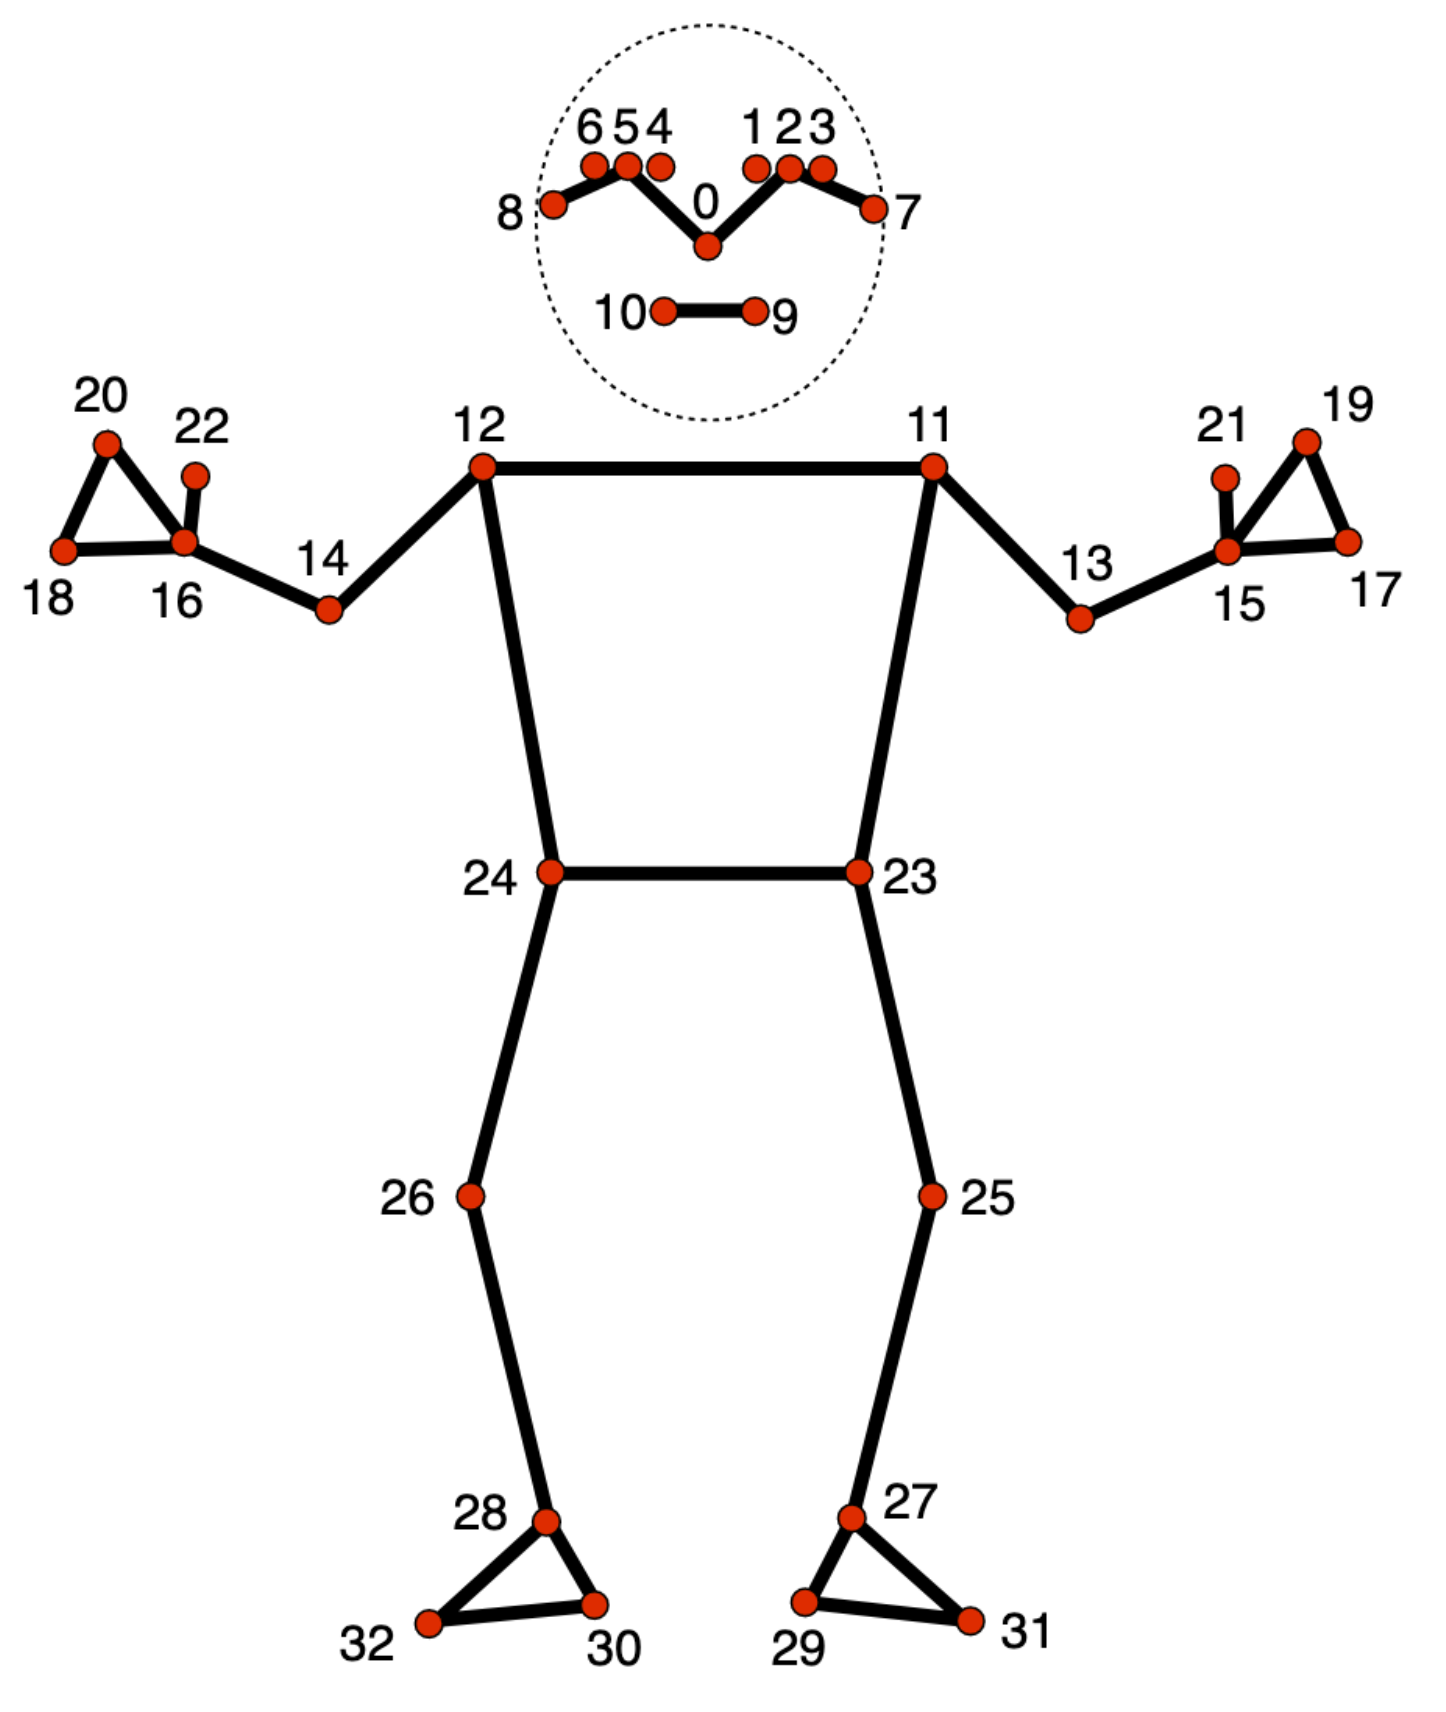

0. nose
1. left eye (inner)
2. left eye
3. left eye (outer)
4. right eye (inner)
5. right eye
6. right eye (outer)

In [ ]:
## HELPER FUNCTIONS ##
""" Calculate angle between co-ordinates a, b and c. """
def calculate_angle(a, b, c):
    a = np.array(a) # first
    b = np.array(b) # mid
    c = np.array(c) # end

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0 / np.pi)
    if angle > 180.0:
        angle = 360-angle
    
    return angle

""" Calculate the ratio between the  """
def calculate_ratio(a, b, c):
    a = np.array(a) # first
    b = np.array(b) # mid
    c = np.array(c) # end


## BLINK COUNTER ##

counter = 0
stage = None

cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()

    # recolor to RGB because mediapipe expects RGB, but opencv feed is BGR by default.
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # to save memory
    image.flags.writeable = False
    
    # change back to true so that cv2 can write to it
    image.flags.writeable = True
    # recolor back to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # extract landmarks

    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        output_segmentation_masks=False,
        num_poses=1
    )

    # Landmarker instance...
    landmarker = vision.PoseLandmarker.create_from_options(options)

    
    landmarks = results.pose_landmarks.landmark

    # get coordinates
    shoulder = [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y]
    elbow = [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y]
    wrist = [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y]
    
    # calc angle
    angle = calculate_angle(shoulder, elbow, wrist)
    # visualize angle
    # MULTIPLY BY DIMENSIONS OF WEBCAM FEED
    cv2.putText(image, str(angle),
                tuple(np.multiply(elbow, [640, 480]).astype(int)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA
                )
    
    # curl counter logic:
    if angle > 160:
        stage = "down"
    if angle < 30 and stage =="down":
        stage = "up"
        counter += 1

    # render curl counter
    # setup status box
    cv2.rectangle(image, (0,0), (255,72), (255,0,255), -1)
    cv2.putText(image, "REPS", (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 1, cv2.LINE_AA)
    cv2.putText(image, str(counter), (10,60), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,0), 2, cv2.LINE_AA)

    cv2.putText(image, "STAGE", (65,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 1, cv2.LINE_AA)
    cv2.putText(image, stage, (60,60), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,0), 2, cv2.LINE_AA)

    # change the image that we're actually going to render
    # first drawing spec: landmarks (points) (color is in BGR)
    # second drawing spec: connections (lines)
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                mp_drawing.DrawingSpec(color=(255,255,0), thickness=2, circle_radius=2),
                                mp_drawing.DrawingSpec(color=(255,0,255), thickness=2, circle_radius=2)
                                )

    # render the image
    cv2.imshow('Mediapipe Feed', image)

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41


In [ ]:
cv2.rectangle??